# Task 1: Credit Scoring Model

# Import Libraries and Load Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed: Added 'from' and 'import' keywords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Fixed: Added 'df =' to store the data and updated the path
df = pd.read_csv('/kaggle/input/datasets/seeratfatima02/german-dataset/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [10]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [13]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

# Data Cleaning & Preprocessing

In [14]:
# 1. Handle missing values
# We replace NaN with 'Unknown' so the model can still use the rest of the row
df['Checking account'] = df['Checking account'].fillna('Unknown')
df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')

# 2. Drop the 'Unnamed: 0' column (it's just an index we don't need)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# 3. Label Encoding
# Convert text columns into numerical values
le = LabelEncoder()
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

print("Data Cleaning and Encoding complete!")
df.head()

Data Cleaning and Encoding complete!


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,1
1,22,0,2,1,1,2,5951,48,5,0
2,49,1,1,1,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,1
4,53,1,2,0,1,1,4870,24,1,0


In [15]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

# Feature Engineering

In [16]:
# Feature engineering: Calculating 'Credit per Month'
# This helps the model see how heavy the monthly repayment burden is
df['Credit_per_Month'] = df['Credit amount'] / df['Duration']

print("Feature Engineering complete: 'Credit_per_Month' added.")
df[['Credit amount', 'Duration', 'Credit_per_Month']].head()

Feature Engineering complete: 'Credit_per_Month' added.


,Credit amount,Duration,Credit_per_Month
0,1169,6,194.833333
1,5951,48,123.979167
2,2096,12,174.666667
3,7882,42,187.666667
4,4870,24,202.916667


# Split and Scale

In [17]:
# 1. Define Features (X) and Target (y)
X = df.drop('Risk', axis=1)
y = df['Risk']

# 2. Perform the Split BEFORE scaling
# We use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Scaler
scaler = StandardScaler()

# 4. Fit on TRAIN data only, then transform both
# This prevents the test set's distribution from 'leaking' into the training process
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled correctly. Ready for training without leakage.")

Data split and scaled correctly. Ready for training without leakage.


# Model Training

In [18]:
# Initialize and Train the Random Forest Classifier
# Using 100 trees (n_estimators) for a robust model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Random Forest Model Training complete!")

Random Forest Model Training complete!


# Model Evaluation

--- Task 1: Credit Scoring Model Evaluation ---
              precision    recall  f1-score   support

           0       0.62      0.41      0.49        59
           1       0.78      0.89      0.83       141

    accuracy                           0.75       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73      0.75      0.73       200

ROC-AUC Score: 0.78


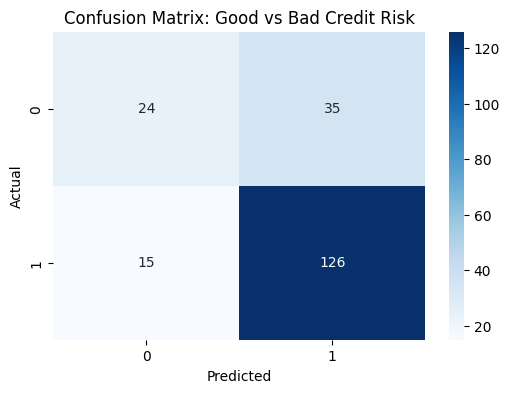

In [19]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make predictions on the unseen test data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 2. Print the required metrics
print("--- Task 1: Credit Scoring Model Evaluation ---")
# This provides Precision, Recall, and F1-Score
print(classification_report(y_test, y_pred)) 

# 3. Calculate and print ROC-AUC
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

# 4. Optional: Visualizing the results with a Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Good vs Bad Credit Risk')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()